MACHINE LEARNING
Seminar 2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import csv
import io
import random
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler, LabelEncoder,  StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = '/content/drive/Shareddrives/MLNETWORKS/SEMIS/S2/dataset_seminar2'


Mounted at /content/drive


Part I: Data preparation & analysis

In [2]:
df = pd.read_csv('/content/drive/Shareddrives/MLNETWORKS/SEMIS/S2/dataset_seminar2/Train_skelletonpoints.csv', sep=',', header=None)
display(df.head(10))

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
0,136.03,198.72,194.99,241.76,201.30,202.46,278.33,351.28,351.28,458.27,...,0.68862,0.78250,0.68072,0.62456,0.68884,0.77941,0.83174,0.840540,0.79928,0.667820
1,202.42,259.99,255.88,313.45,297.00,264.10,317.56,387.46,383.35,473.81,...,0.60709,0.82400,0.75419,0.65880,0.80821,0.77518,0.86345,0.876270,0.62875,0.629860
2,193.42,250.56,254.64,340.35,397.49,246.48,319.94,270.97,401.57,479.12,...,0.31261,0.57599,0.68195,0.25706,0.27761,0.26193,0.95407,0.128050,0.89682,0.008460
3,205.81,257.79,255.71,301.45,268.18,259.87,313.92,388.78,380.46,471.95,...,0.75569,0.89123,0.70243,0.65057,0.72541,0.75135,0.78706,0.774260,0.63834,0.717970
4,289.49,303.86,300.27,354.16,415.24,307.46,354.16,404.46,364.94,451.17,...,0.43415,0.59738,0.66353,0.51422,0.79301,0.73571,0.67160,0.323880,0.78987,0.008824
5,360.70,316.07,317.72,354.08,423.50,314.42,354.08,416.89,340.86,459.87,...,0.56845,0.61904,0.60180,0.31584,0.39940,0.18240,0.87548,0.023613,0.89182,0.008884
6,164.20,221.80,221.80,301.54,332.56,221.80,292.68,323.70,354.71,452.18,...,0.76418,0.75357,0.76965,0.68287,0.85687,0.93174,0.89225,0.878170,0.62280,0.758890
7,180.35,223.35,220.99,302.26,266.26,225.70,272.54,270.64,399.34,473.61,...,0.48707,0.60230,0.66747,0.37093,0.41956,0.39981,0.84413,0.059907,0.75432,0.013039
8,163.96,229.23,229.23,294.50,264.04,229.23,298.85,364.12,385.88,477.26,...,0.54529,0.63186,0.74941,0.49792,0.60808,0.86344,0.84678,0.862390,0.60577,0.793990
9,126.02,181.95,179.52,233.01,198.97,184.38,267.05,330.27,325.40,437.25,...,0.72584,0.78501,0.77104,0.70588,0.69363,0.86506,0.75568,0.836190,0.50147,0.568340


# **Part I: Data preparation & analysis**

## **Create a function/script that takes SkelletonPoints as input and plots the corresponding pose. Your plotting function should also display the label associated with the pose being plotted.**

In [3]:
print(df.iloc[0:2].values)

[[1.3603e+02 1.9872e+02 1.9499e+02 2.4176e+02 2.0130e+02 2.0246e+02
  2.7833e+02 3.5128e+02 3.5128e+02 4.5827e+02 5.6526e+02 3.5614e+02
  4.5827e+02 5.5554e+02 1.2469e+02 1.2620e+02 1.3792e+02 1.4050e+02
  2.2430e+02 2.2111e+02 2.8305e+02 3.4968e+02 2.8804e+02 1.5917e+02
  1.2821e+02 1.4280e+02 2.5465e+02 2.4979e+02 2.5952e+02 1.8657e+02
  1.6711e+02 1.7198e+02 2.3698e+02 2.0880e+02 2.5767e+02 1.9100e+02
  8.9233e-01 6.6412e-01 6.4404e-01 7.6874e-01 7.3817e-01 6.8419e-01
  8.7514e-01 8.8166e-01 6.8862e-01 7.8250e-01 6.8072e-01 6.2456e-01
  6.8884e-01 7.7941e-01 8.3174e-01 8.4054e-01 7.9928e-01 6.6782e-01]
 [2.0242e+02 2.5999e+02 2.5588e+02 3.1345e+02 2.9700e+02 2.6410e+02
  3.1756e+02 3.8746e+02 3.8335e+02 4.7381e+02 5.6016e+02 3.8746e+02
  4.7381e+02 5.6016e+02 1.9420e+02 1.9420e+02 2.0653e+02 2.0653e+02
  2.5328e+02 2.4300e+02 2.9851e+02 3.4785e+02 3.0673e+02 1.8749e+02
  1.6281e+02 1.5870e+02 2.7795e+02 2.7384e+02 2.7795e+02 2.1627e+02
  2.2861e+02 2.3683e+02 2.6561e+02 2.4094e+02 2

In [4]:
def plot_pose(Skpoints):
    x_points = []
    y_points = []
    for i in range(18):
        x_points.append(Skpoints[i])
        y_points.append(Skpoints[18+i])

    plt.plot(x_points, y_points, marker='o', linestyle='-')
    plt.xlabel('X points')
    plt.ylabel('Y points')
    plt.title('Pose')
    plt.grid(True)
    plt.show()

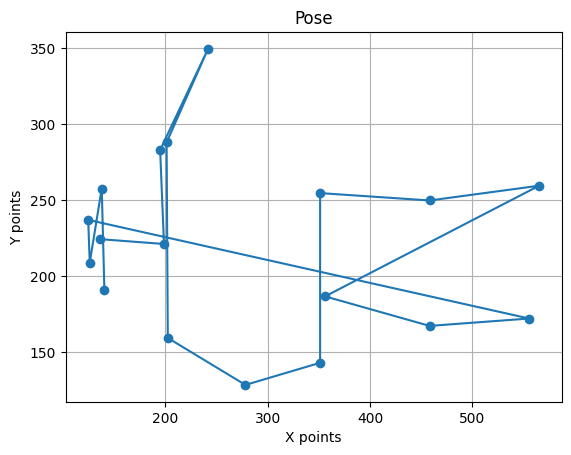

In [5]:
plot_pose(df.iloc[0])

In [6]:
# 1) CSI features
train_X    = pd.read_csv(os.path.join(BASE_PATH, 'Train_features.csv'),       header=None)
test_X     = pd.read_csv(os.path.join(BASE_PATH, 'Test_features.csv'),        header=None)

# 2) Puntos de esqueleto
skel_train = pd.read_csv(os.path.join(BASE_PATH, 'Train_skelletonpoints.csv'), header=None, sep=',')
skel_test  = pd.read_csv(os.path.join(BASE_PATH, 'Test_skelletonpoints.csv'),  header=None, sep=',')

# 3) Labels (vienen en una fila; convertimos a Serie 1D)
train_y = pd.read_csv(os.path.join(BASE_PATH, 'Train_labels.csv'), header=None, sep=',')
train_y = train_y.T[0]

test_y  = pd.read_csv(os.path.join(BASE_PATH, 'Test_labels.csv'),  header=None, sep=',')
test_y  = test_y.T[0]

# 4) Comprobamos shapes
print("train_X:   ", train_X.shape)    # → (1000, 270)
print("train_y:   ", train_y.shape)    # → (1000,)
print("skel_train:", skel_train.shape) # → (1000, 54)
print("test_X:    ", test_X.shape)     # → (200, 270)
print("test_y:    ", test_y.shape)     # → (200,)
print("skel_test: ", skel_test.shape)  # → (400, 54)


train_X:    (1000, 270)
train_y:    (1000,)
skel_train: (1000, 54)
test_X:     (200, 270)
test_y:     (200,)
skel_test:  (400, 54)


'connections'
Se usa para unir articulaciones con líneas y formar la estructura humana.

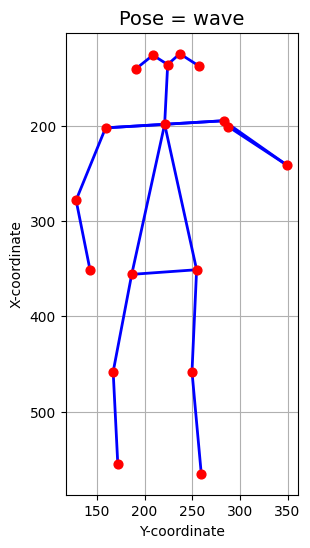

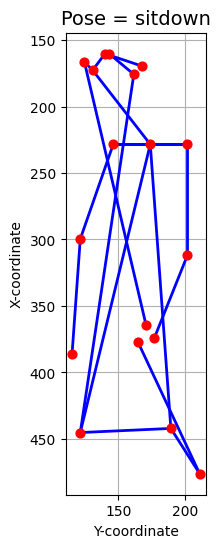

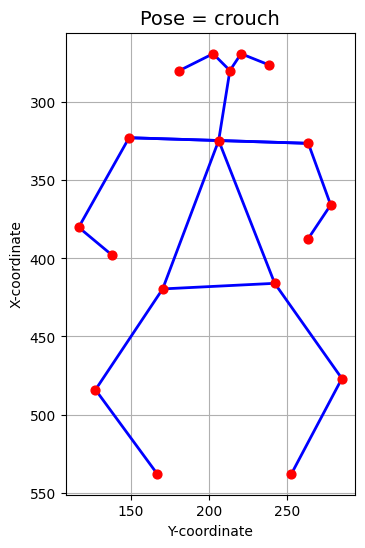

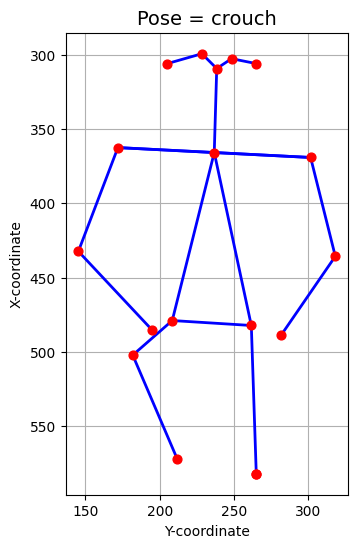

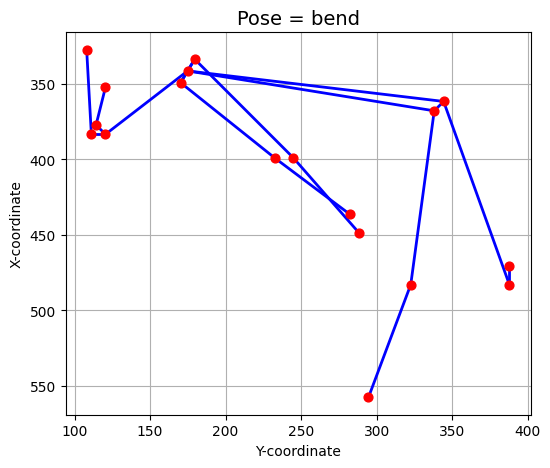

In [7]:

connections = [
    (0, 1),   # 1–2  Nose – Neck
    (1, 2),   # 2–3  Neck – Right Shoulder
    (2, 3),   # 3–4  Right Shoulder – Right Elbow
    (3, 4),   # 4–5  Right Elbow – Right Wrist
    (1, 5),   # 2–6  Neck – Left Shoulder
    (5, 6),   # 6–7  Left Shoulder – Left Elbow
    (6, 7),   # 7–8  Left Elbow – Left Wrist
    (1, 8),   # 2–9  Neck – Right Hip
    (8, 9),   # 9–10 Right Hip – Right Knee
    (9, 10),  # 10–11 Right Knee – Right Ankle
    (1, 11),  # 2–12 Neck – Left Hip
    (11, 12), # 12–13 Left Hip – Left Knee
    (12, 13), # 13–14 Left Knee – Left Ankle
    (0, 14),  # 1–15 Nose – Right Eye
    (0, 15),  # 1–16 Nose – Left Eye
    (14, 16), # 15–17 Right Eye – Right Ear
    (15, 17), # 16–18 Left Eye – Left Ear
    (2, 5),   # 3–6  Right Shoulder – Left Shoulder
    (8, 11)   # 9–12 Right Hip – Left Hip
]

pose_map = {1:'wave', 2:'push', 3:'crouch', 4:'sitdown', 5:'bend'}

def plot_skeleton(i):
    pts = skel_train.iloc[i].values
    x   = pts[:18]
    y   = pts[18:36]
    lbl = int(train_y[i])
    name = pose_map.get(lbl, lbl)

    plt.figure(figsize=(6,6))
    for a, b in connections:
        plt.plot([y[a], y[b]], [x[a], x[b]],
                 '-', color='blue', linewidth=2)
    plt.scatter(y, x, color='red', s=40, zorder=3)

    plt.title(f'Pose = {name}', fontsize=14)
    plt.xlabel('Y-coordinate')
    plt.ylabel('X-coordinate')
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.gca().set_aspect('equal', 'box')
    plt.show()


# Prueba
plot_skeleton(0)
plot_skeleton(25)
plot_skeleton(50)
plot_skeleton(75)
plot_skeleton(100)


Here we can see some of the poses we have in our dataset

## **Now, focus on the CSI data (for instance, from Train features.csv) and implement the code for plotting the average CSI amplitude per subcarrier. Such a plot should allow for understanding the status of the channel at a given specific moment and for a specific subcarrier.**

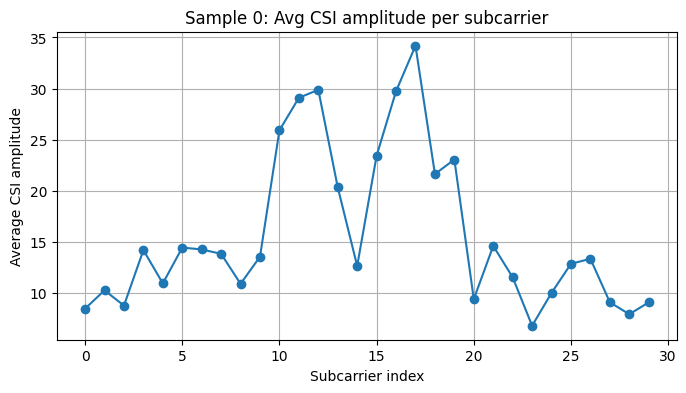

In [8]:
idx = 0

csi = train_X.iloc[idx].values.reshape(30, 9)

# 2) Calcula el módulo (amplitud) y luego la media sobre los 9 enlaces
amp_mean = np.abs(csi).mean(axis=1)

# 3) Dibuja
plt.figure(figsize=(8,4))
plt.plot(np.arange(30), amp_mean, marker='o', linestyle='-')
plt.xlabel('Subcarrier index')
plt.ylabel('Average CSI amplitude')
plt.title(f'Sample {idx}: Avg CSI amplitude per subcarrier')
plt.grid(True)
plt.show()


This graph shows that subcarriers between frequencies 10 and 18 exhibit significant amplitude peaks, indicating greater interaction of the human body with these frequencies. Flatter regions (such as 0–9 and 21–29) have less variability and likely provide less useful information. These differences suggest that certain subcarriers are more relevant for distinguishing poses.

## **CSI Distribution**

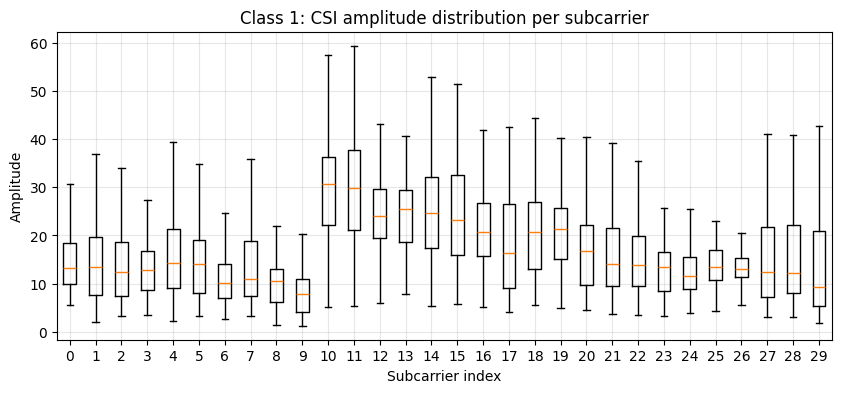

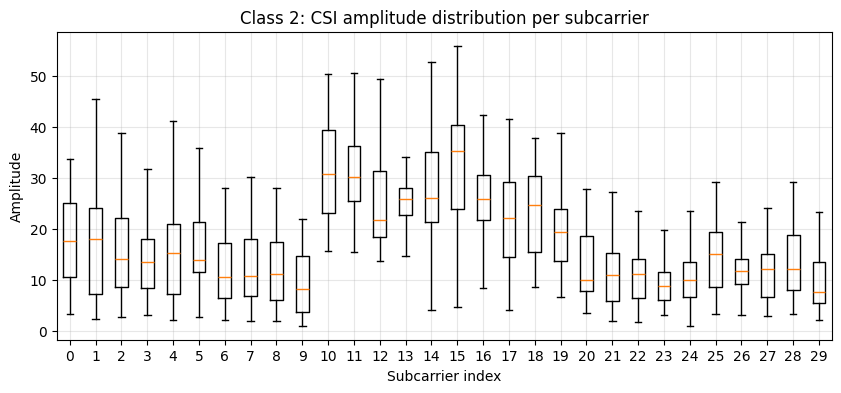

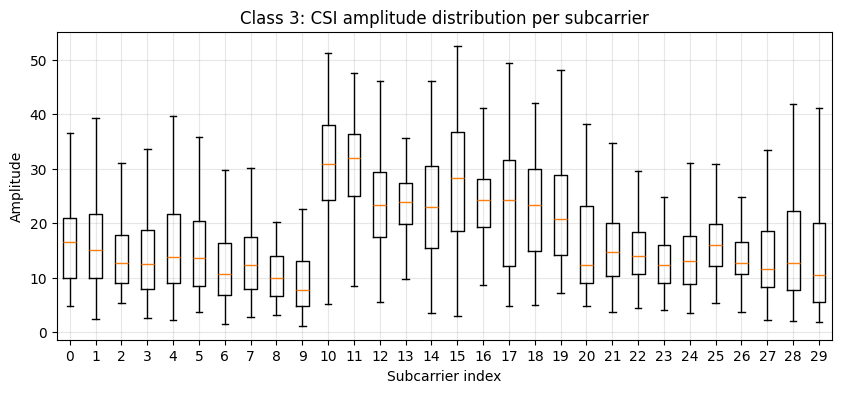

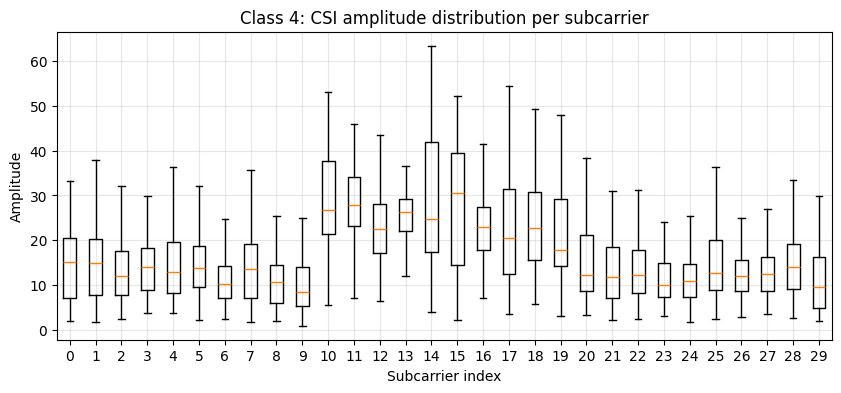

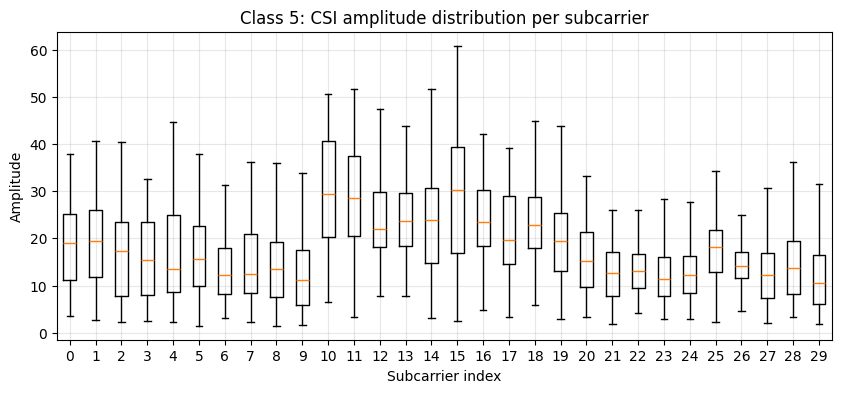

In [9]:
# Reshape of the dataset: (N_samples, 270) to (N_samples, 30, 9)
arr = train_X.values.reshape(-1, 30, 9)
# Mean amplitude per subcarrier (N_samples, 30)
amp_data = np.abs(arr).mean(axis=2)


labels = train_y.astype(int).values

# Boxplot of 30 subcarriers per class
for cls in np.unique(labels):
    cls_samples = amp_data[labels == cls]
    plt.figure(figsize=(10,4))
    plt.boxplot(
        cls_samples,
        tick_labels=np.arange(30),
        showfliers=False
    )
    plt.title(f'Class {cls}: CSI amplitude distribution per subcarrier')
    plt.xlabel('Subcarrier index')
    plt.ylabel('Amplitude')
    plt.grid(alpha=0.3)
    plt.show()


Class 1:
Subcarriers 10 to 20 show a higher median and greater dispersion, indicating that these frequencies are more influenced by the pose associated with this class. The remaining subcarriers have more homogeneous behavior.

Class 2:
The distribution has pronounced peaks between indices 10 and 17, similar to class 1, but with slightly higher medians and greater variability. This can help differentiate them.

Class 3:
This pattern is very similar to class 2, with high amplitudes between subcarriers 10 and 18. The differences may be subtle and depend on the exact shape of the boxes (dispersion, outliers, etc.).

Class 4:
This has a more balanced behavior but with a significant increase between indices 10 and 15. The average amplitude here is lower than in previous classes, but still significant.

Class 5:
Distribution similar to class 4, although with a slightly wider dispersion in the 10–20 indices. The medians are slightly higher.

# **Part II: Model implementation**


## **Create a module that loads the training data and fits it into an SVM. You can leverage existing libraries that implement SVMs (e.g., pytorch).**


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_X)
X_test_scaled  = scaler.transform(test_X)

# Definition and training of the classifier SVM
svm_clf = SVC(kernel='rbf', random_state=42)
svm_clf.fit(X_train_scaled, train_y)

SVC(random_state=42)

## **Generate predictions on the test dataset using the SVM trained in the previous step. For evaluating the SVM, you should define one or more success rate metrics.**

Accuracy (test): 0.7700


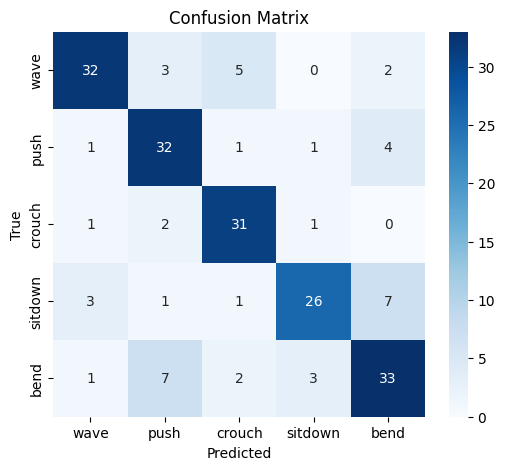

Classification report:
              precision    recall  f1-score   support

        wave       0.84      0.76      0.80        42
        push       0.71      0.82      0.76        39
      crouch       0.78      0.89      0.83        35
     sitdown       0.84      0.68      0.75        38
        bend       0.72      0.72      0.72        46

    accuracy                           0.77       200
   macro avg       0.78      0.77      0.77       200
weighted avg       0.78      0.77      0.77       200



In [11]:
# Confusion matrix of predictions

y_pred = svm_clf.predict(X_test_scaled)

acc = accuracy_score(test_y, y_pred)
print(f'Accuracy (test): {acc:.4f}')

cm = confusion_matrix(test_y, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[pose_map[i] for i in sorted(pose_map)],
            yticklabels=[pose_map[i] for i in sorted(pose_map)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print('Classification report:')
print(classification_report(test_y, y_pred,
                            target_names=[pose_map[i] for i in sorted(pose_map)]))

Wave: 32/42 well classified.

Push: 32/39 well classified.

Crouch: 31/35 well classified.

Sitdown: only 26/38 well classified.

Bend: 33/46 well classified.

With these results we can conclude that the model classifies reasonably well, with a general accuracy of 77%. The majority of mistakes happen because of the visual similarity between some poses (sitdown and bend, wave and crouch). The model could be imporved using some techniques like data augmentation or with more complex models.